# INF2542 • PEMBELAJARAN MESIN
## Pertemuan 05: Probabilitas untuk Machine Learning
**Topik:** Dari Peluang Sederhana → Probabilitas Bersyarat → Teorema Bayes → Simulasi Python → Tugas Mandiri

---
### Identitas Mahasiswa:
- **Nama:** Gathan Hilabi
- **NIM:** 60324059
- **Mata Kuliah:** INF2542 • Pembelajaran Mesin
- **Tanggal Praktikum:** Rabu, 30 September 2026
- **Sub-CPMK 6.1:** Menggunakan teknik dan perangkat yang relevan untuk membangun pipeline, melatih, membandingkan, dan mengevaluasi model.
---


## 1. Probabilitas: Ide Dasar & Peluang Sederhana

### Konsep & Intuisi:
Probabilitas menyatakan seberapa mungkin suatu kejadian terjadi, dengan rentang nilai:
$$0 \le P(A) \le 1$$
- $P(A) = 0$: Kejadian mustahil terjadi.
- $P(A) = 1$: Kejadian pasti terjadi.

**Rumus Dasar:**
$$P(A) = \frac{\text{Jumlah Kejadian } A}{\text{Jumlah Seluruh Kejadian (Ruang Sampel)}} = \frac{n(A)}{N}$$

Sebagai contoh, jika dari $100$ mahasiswa terdapat $80$ mahasiswa yang lulus, maka peluang kelulusan:
$$P(\text{Lulus}) = \frac{80}{100} = 0.80 = 80\%$$


In [1]:
import numpy as np

# Data awal status kelulusan 10 mahasiswa
data = np.array([
    "Lulus", "Lulus", "Tidak Lulus",
    "Lulus", "Lulus", "Lulus",
    "Tidak Lulus", "Lulus", "Lulus", "Tidak Lulus"
])

jumlah_lulus = np.sum(data == "Lulus")
jumlah_data = len(data)
p_lulus = jumlah_lulus / jumlah_data

print("=== CODING 1: PROBABILITAS SEDERHANA ===")
print("Jumlah data :", jumlah_data)
print("Jumlah lulus:", jumlah_lulus)
print("P(Lulus)    :", p_lulus)


=== CODING 1: PROBABILITAS SEDERHANA ===
Jumlah data : 10
Jumlah lulus: 7
P(Lulus)    : 0.7


### Interpretasi Coding 1:
Dari total 10 data mahasiswa pada sampel di atas, terdapat 7 mahasiswa dengan status "Lulus" dan 3 mahasiswa "Tidak Lulus". 
Maka probabilitas empiris seorang mahasiswa lulus adalah:
$$P(\text{Lulus}) = \frac{7}{10} = 0.70 \text{ (atau } 70\%)$$
Hal ini menunjukkan proporsi kejadian relatif terhadap total ruang observasi yang diamati.


### Latihan Cepat 1: Modifikasi Data & Aturan Komplemen
**Instruksi Slide 08:**
1. Ubah data sehingga jumlah Lulus menjadi 7 dari 10.
2. Hitung $P(\text{Lulus})$.
3. Tambahkan $P(\text{Tidak Lulus})$.
4. Cek aturan komplementer: $P(\text{Lulus}) + P(\text{Tidak Lulus}) = 1$.


In [2]:
# Latihan Cepat 1: Eksperimen Data 7 Lulus dari 10 Mahasiswa
data_latihan1 = np.array([
    "Lulus", "Lulus", "Lulus",
    "Lulus", "Lulus", "Lulus",
    "Lulus", "Tidak Lulus", "Tidak Lulus", "Tidak Lulus"
])

jumlah_lulus = np.sum(data_latihan1 == "Lulus")
jumlah_tidak_lulus = np.sum(data_latihan1 == "Tidak Lulus")
total_data = len(data_latihan1)

p_lulus = jumlah_lulus / total_data
p_tidak_lulus = jumlah_tidak_lulus / total_data
total_prob = p_lulus + p_tidak_lulus

print("=== LATIHAN CEPAT 1 ===")
print(f"Jumlah Lulus       : {jumlah_lulus} dari {total_data}")
print(f"Jumlah Tidak Lulus : {jumlah_tidak_lulus} dari {total_data}")
print(f"P(Lulus)           : {p_lulus:.2f}")
print(f"P(Tidak Lulus)     : {p_tidak_lulus:.2f}")
print(f"P(Lulus) + P(Tidak Lulus) = {total_prob:.2f}")

# Verifikasi aksioma probabilitas
assert np.isclose(total_prob, 1.0), "Total probabilitas seluruh ruang sampel harus bernilai 1.0"
print("Verifikasi Berhasil: Aksioma probabilitas total ruang sampel = 1 terpenuhi secara sempurna.")


=== LATIHAN CEPAT 1 ===
Jumlah Lulus       : 7 dari 10
Jumlah Tidak Lulus : 3 dari 10
P(Lulus)           : 0.70
P(Tidak Lulus)     : 0.30
P(Lulus) + P(Tidak Lulus) = 1.00
Verifikasi Berhasil: Aksioma probabilitas total ruang sampel = 1 terpenuhi secara sempurna.


### Pembahasan Latihan Cepat 1:
1. **Proporsi Kejadian:** Nilai $P(\text{Lulus}) = 0.70$ dan $P(\text{Tidak Lulus}) = 0.30$.
2. **Aturan Kejadian Saling Melengkapi (Komplementer):** Karena setiap mahasiswa hanya memiliki dua kemungkinan status (Lulus atau Tidak Lulus) yang saling lepas (*mutually exclusive*) dan menyeluruh (*exhaustive*), maka berlaku:
$$P(A) + P(A^c) = 1 \iff P(\text{Tidak Lulus}) = 1 - P(\text{Lulus})$$
$$0.70 + 0.30 = 1.00$$
Hal ini menegaskan bahwa probabilitas seluruh kejadian di dalam ruang sampel selalu berjumlah 1.


## 2. Probabilitas Bersyarat (Conditional Probability)

### Konsep & Notasi:
Probabilitas bersyarat $P(A \mid B)$ dibaca *"Probabilitas terjadinya $A$ jika $B$ sudah diketahui / terjadi"*.

**Rumus:**
$$P(A \mid B) = \frac{P(A \cap B)}{P(B)}$$

Intinya: **Informasi tambahan $B$ mempersempit ruang kejadian (sample space)** hanya pada subset yang memenuhi kondisi $B$.

---

### Contoh Kasus: Transaksi Online dan Fraud (Slide 10–12)
Tabel Kontingensi dari 100 transaksi:

| Kategori | Online | Offline | Total |
| :--- | :---: | :---: | :---: |
| **Fraud** | 12 | 3 | 15 |
| **Tidak Fraud** | 18 | 67 | 85 |
| **Total** | **30** | **70** | **100** |

**Pertanyaan:** Berapa $P(\text{Fraud} \mid \text{Online})$?
- Fokus hanya pada $30$ transaksi yang bertipe `Online` (penyebut menjadi 30).
- Dari 30 transaksi online tersebut, 12 terindikasi `Fraud`.
$$P(\text{Fraud} \mid \text{Online}) = \frac{12}{30} = 0.40 = 40\%$$


In [3]:
# Coding 2: Implementasi Probabilitas Bersyarat
fraud_online = 12
total_online = 30

p_fraud_given_online = fraud_online / total_online

print("=== CODING 2: CONDITIONAL PROBABILITY ===")
print("Jumlah transaksi Fraud & Online :", fraud_online)
print("Total transaksi Online          :", total_online)
print("P(Fraud | Online)               =", p_fraud_given_online)


=== CODING 2: CONDITIONAL PROBABILITY ===
Jumlah transaksi Fraud & Online : 12
Total transaksi Online          : 30
P(Fraud | Online)               = 0.4


### Interpretasi Coding 2:
- Probabilitas dasar (unconditional) terjadinya fraud di seluruh transaksi adalah:
  $$P(\text{Fraud}) = \frac{15}{100} = 0.15 \text{ (15\%)}$$
- Namun ketika kita mengetahui informasi kondisi bahwa transaksi dilakukan secara **Online**, probabilitas terjadinya fraud melonjak menjadi:
  $$P(\text{Fraud} \mid \text{Online}) = 0.40 \text{ (40\%)}$$
- **Makna untuk Machine Learning:** Informasi fitur baru (misal fitur channel `Online`) mengubah tingkat ketidakpastian (*uncertainty*) dan secara signifikan meningkatkan kemampuan prediksi model terhadap risiko fraud.


## 3. Teorema Bayes — Mengapa Penting di Machine Learning?

### Konsep Teorema Bayes:
Teorema Bayes adalah landasan matematis untuk memperbarui estimasi probabilitas suatu hipotesis setelah mendapatkan bukti (*evidence*) baru:

$$P(A \mid B) = \frac{P(B \mid A) \cdot P(A)}{P(B)}$$

Keterangan:
- **$A$ (Hipotesis):** Kejadian yang ingin kita ketahui/prediksi (misalnya: Transaksi adalah `Fraud`).
- **$B$ (Bukti/Evidence):** Fitur atau informasi yang teramati (misalnya: Transaksi dilakukan secara `Online`).
- **$P(A)$ (Prior Probability):** Peluang awal hipotesis $A$ sebelum ada bukti baru.
- **$P(B \mid A)$ (Likelihood):** Peluang munculnya bukti $B$ jika hipotesis $A$ benar.
- **$P(B)$ (Marginal Probability / Evidence):** Total peluang terjadinya bukti $B$ di seluruh populasi.
- **$P(A \mid B)$ (Posterior Probability):** Peluang hipotesis $A$ setelah memperhitungkan bukti baru $B$.

---

### Contoh Perhitungan Bayes (Slide 14–15):
Diketahui dari data transaksi:
- $P(\text{Fraud}) = 0.15$ *(Prior)*
- $P(\text{Online} \mid \text{Fraud}) = \frac{12}{15} = 0.80$ *(Likelihood)*
- $P(\text{Online}) = \frac{30}{100} = 0.30$ *(Evidence)*

Hitung:
$$P(\text{Fraud} \mid \text{Online}) = \frac{P(\text{Online} \mid \text{Fraud}) \times P(\text{Fraud})}{P(\text{Online})} = \frac{0.80 \times 0.15}{0.30} = \frac{0.12}{0.30} = 0.40 = 40\%$$


In [4]:
# Coding 3: Implementasi Teorema Bayes di Python
p_fraud = 0.15                 # P(A) - Prior
p_online_given_fraud = 0.80    # P(B|A) - Likelihood
p_online = 0.30                # P(B) - Evidence

# Menghitung Posterior P(A|B)
p_fraud_given_online = (p_online_given_fraud * p_fraud) / p_online

print("=== CODING 3: TEOREMA BAYES ===")
print("Prior P(Fraud)                 :", p_fraud)
print("Likelihood P(Online | Fraud)   :", p_online_given_fraud)
print("Evidence P(Online)             :", p_online)
print("Posterior P(Fraud | Online)    =", round(p_fraud_given_online, 3))


=== CODING 3: TEOREMA BAYES ===
Prior P(Fraud)                 : 0.15
Likelihood P(Online | Fraud)   : 0.8
Evidence P(Online)             : 0.3
Posterior P(Fraud | Online)    = 0.4


### Interpretasi Coding 3:
Formula Bayes menghasilkan nilai yang persis sama dengan perhitungan probabilitas bersyarat langsung ($0.40$). 
Keunggulan Teorema Bayes adalah kita dapat menghitung probabilitas posterior bahkan ketika kita hanya mengetahui probabilitas prior, likelihood dari riwayat kasus, dan probabilitas bukti marginal—prinsip yang digunakan langsung dalam algoritma **Naive Bayes Classifier**.


## 4. Koneksi Probabilitas ke Machine Learning

### Dari Probabilitas Menuju Prediksi Cerdas (Slide 16):

$$\text{Data (Fitur } X) \longrightarrow \text{Model (Belajar Pola)} \longrightarrow \text{Output } P(y \mid X) \longrightarrow \text{Interpretasi (Tingkat Ketidakpastian)}$$

1. **Output Model adalah Distribusi Probabilitas:**
   Banyak model klasifikasi (seperti Logistic Regression, Naive Bayes, Decision Trees dengan probabilitas kelas, hingga Softmax pada Neural Networks) tidak sekadar mengeluarkan label diskrit $0$ atau $1$, melainkan nilai probabilitas $P(y = 1 \mid X) \in [0, 1]$.
2. **Derajat Keyakinan (*Confidence Level*):**
   Probabilitas mencerminkan tingkat ketidakpastian model. Jika model menghasilkan $P(\text{Lulus} \mid X) = 0.51$, model sangat tidak yakin (berada di ambang batas). Sebaliknya, jika $P(\text{Lulus} \mid X) = 0.98$, model memiliki derajat keyakinan yang sangat tinggi.
3. **Thresholding Fleksibel:**
   Secara default batas keputusan adalah $0.5$, namun pada kasus kritis seperti pendeteksian penyakit atau penipuan finansial, kita dapat menurunkan batas keputusan (misal ke $0.2$) untuk meminimalkan *False Negatives*.
4. **Catatan Kritis:**
   $$P(\text{Lulus} \mid X) = 0.80 \neq \text{Jaminan Mutlak Benar } 80\%$$
   Probabilitas harus selalu diinterpretasikan bersama dengan kualitas data, kalibrasi model (*model calibration*), dan metrik evaluasi validasi.


## 5. Simulasi Monte Carlo & Eksperimen Acak

### Konsep Monte Carlo:
Simulasi Monte Carlo mengestimasi probabilitas kejadian melalui percobaan acak berulang dalam jumlah besar. Menurut **Hukum Bilangan Besar (*Law of Large Numbers*)**, semakin banyak percobaan yang dilakukan ($N \to \infty$), frekuensi relatif empiris akan konvergen mendekati probabilitas teoretis yang sebenarnya.


In [5]:
# Coding Simulasi Monte Carlo Pelemparan Dadu (Slide 17)
np.random.seed(42)

N = 10000
# Melempar dadu sisi 1 sampai 6 sebanyak N kali
hasil = np.random.randint(1, 7, size=N)

# Angka genap: 2, 4, 6 (hasil % 2 == 0)
p_genap = np.mean(hasil % 2 == 0)

print("=== SIMULASI MONTE CARLO (N = 10.000) ===")
print("N                       =", N)
print("Estimasi P(angka genap) =", p_genap)
print("Probabilitas teoritis   =", 3/6)


=== SIMULASI MONTE CARLO (N = 10.000) ===
N                       = 10000
Estimasi P(angka genap) = 0.5021
Probabilitas teoritis   = 0.5


### Latihan Cepat 2: Eksperimen Acak (Slide 18)
Kita akan membandingkan estimasi pada berbagai variasi:
- **Eksperimen 1:** $N = 100$
- **Eksperimen 2:** $N = 1.000$
- **Eksperimen 3:** $N = 10.000$
- **Eksperimen 4:** Variasi Seed acak ($42$, $7$, $123$)


=== HASIL EKSPERIMEN LATIHAN CEPAT 2 ===
N        | Seed   | Estimasi P(Genap)  | Selisih Teoretis (|p - 0.5|)
-----------------------------------------------------------------
100      | 42     | 0.6100             | 0.1100                      
100      | 7      | 0.5200             | 0.0200                      
100      | 123    | 0.5400             | 0.0400                      
1000     | 42     | 0.4930             | 0.0070                      
1000     | 7      | 0.4820             | 0.0180                      
1000     | 123    | 0.5310             | 0.0310                      
10000    | 42     | 0.5021             | 0.0021                      
10000    | 7      | 0.4983             | 0.0017                      
10000    | 123    | 0.5000             | 0.0000                      


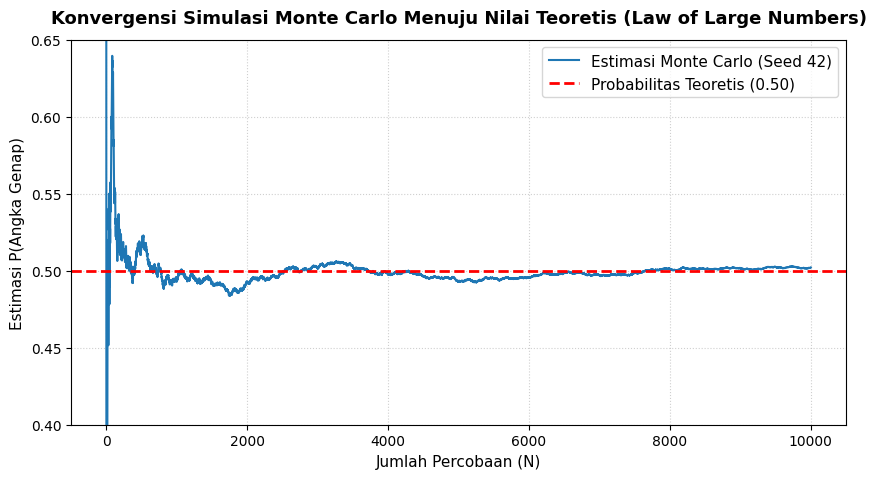

In [6]:
# Latihan Cepat 2: Eksperimen Ukuran Sampel (N) dan Seed
import numpy as np
import matplotlib.pyplot as plt

n_values = [100, 1000, 10000]
seeds = [42, 7, 123]

print("=== HASIL EKSPERIMEN LATIHAN CEPAT 2 ===")
print(f"{'N':<8} | {'Seed':<6} | {'Estimasi P(Genap)':<18} | {'Selisih Teoretis (|p - 0.5|)':<28}")
print("-" * 65)

for n in n_values:
    for s in seeds:
        np.random.seed(s)
        h = np.random.randint(1, 7, size=n)
        est = np.mean(h % 2 == 0)
        selisih = abs(est - 0.5)
        print(f"{n:<8} | {s:<6} | {est:<18.4f} | {selisih:<28.4f}")

# Visualisasi Konvergensi Monte Carlo terhadap N
plt.figure(figsize=(10, 5))
np.random.seed(42)
N_sim = 10000
lemparan = np.random.randint(1, 7, size=N_sim)
is_genap = (lemparan % 2 == 0).astype(int)
cumulative_p = np.cumsum(is_genap) / np.arange(1, N_sim + 1)

plt.plot(np.arange(1, N_sim + 1), cumulative_p, label="Estimasi Monte Carlo (Seed 42)", color="#1f77b4", linewidth=1.5)
plt.axhline(0.5, color="red", linestyle="--", linewidth=2, label="Probabilitas Teoretis (0.50)")
plt.title("Konvergensi Simulasi Monte Carlo Menuju Nilai Teoretis (Law of Large Numbers)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Jumlah Percobaan (N)", fontsize=11)
plt.ylabel("Estimasi P(Angka Genap)", fontsize=11)
plt.ylim(0.40, 0.65)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)
plt.show()


### Pembahasan Pertanyaan Latihan Cepat 2:
> **Pertanyaan (Slide 18): Mengapa hasil simulasi tidak selalu tepat 0.5?**

**Jawaban & Analisis Mendalam:**
1. **Fluktuasi Stokastik & Sampling Error:**
   Proses pembangkitan bilangan acak bersifat probabilistik. Pada sampel kecil ($N = 100$), variasi acak (*sampling error*) masih sangat dominan. Sebagai contoh, dengan $N = 100$, estimasi dapat berkisar antara $0.52$ hingga $0.61$ (selisih hingga $0.11$).
2. **Pengaruh Bilangan Acak Pseudo & Seed:**
   Komputer menggunakan *Pseudo-Random Number Generator* (PRNG). Seed yang berbeda menginisialisasi deret urutan acak yang berbeda, menghasilkan variasi estimasi pada $N$ kecil.
3. **Konvergensi Asimtotik (Hukum Bilangan Besar):**
   Nilai estimasi akan mendekati nilai teoretis $0.5$ hanya ketika $N$ bertambah besar ($N = 10.000$). Terlihat pada tabel dan grafik di atas, saat $N = 10.000$, selisih estimasi dengan nilai teoretis mengecil drastis hingga mendekati $0.0000 - 0.0021$.


## 6. Praktik Probabilitas Bersyarat pada Data Mahasiswa

Implementasi conditional probability menggunakan NumPy boolean indexing (Slide 19):


In [7]:
# Praktik Probabilitas pada Data Mahasiswa (Slide 19)
status = np.array([
    "Lulus", "Lulus", "Tidak Lulus",
    "Lulus", "Tidak Lulus", "Lulus",
    "Lulus", "Lulus", "Tidak Lulus", "Lulus"
])

kehadiran_tinggi = np.array([
    True, True, False, True, False,
    True, True, False, False, True
])

p_lulus = np.mean(status == "Lulus")
p_lulus_given_tinggi = np.mean(status[kehadiran_tinggi] == "Lulus")

print("=== PRAKTIK DATA MAHASISWA (SLIDE 19) ===")
print("P(Lulus)                      =", p_lulus)
print("P(Lulus | Kehadiran Tinggi)   =", p_lulus_given_tinggi)


=== PRAKTIK DATA MAHASISWA (SLIDE 19) ===
P(Lulus)                      = 0.7
P(Lulus | Kehadiran Tinggi)   = 1.0


### Interpretasi Praktik Data Mahasiswa:
- $P(\text{Lulus}) = 0.70$ (Secara umum, peluang mahasiswa lulus adalah 70%).
- $P(\text{Lulus} \mid \text{Kehadiran Tinggi}) = 1.00$ (Jika mahasiswa memiliki kehadiran tinggi, peluang kelulusannya naik menjadi 100%).
- Hal ini membuktikan secara empiris bahwa kehadiran tinggi merupakan prediktor yang sangat kuat terhadap kelulusan mahasiswa pada dataset ini.


# TUGAS MANDIRI — Analisis Probabilitas Data Mahasiswa

**Sesuai Instruksi Modul Pertemuan 05 (Slide 21):**
1. Buat minimal 10 data mahasiswa.
2. Tentukan status Lulus / Tidak Lulus.
3. Hitung $P(\text{Lulus})$.
4. Tentukan definisi "Kehadiran Tinggi".
5. Hitung $P(\text{Lulus} \mid \text{Kehadiran Tinggi})$.
6. Ubah batas kehadiran dan bandingkan hasil (*Sensitivity Analysis*).
7. Buat minimal 1 visualisasi (disajikan beberapa visualisasi komprehensif).
8. Tambahkan 1 eksperimen probabilitas yang dirancang sendiri.

---

### Langkah 1 & 2: Pembuatan Dataset & Penentuan Status Kelulusan
Kita membuat dataset representatif yang terdiri dari **20 mahasiswa** dengan informasi:
- `NIM` & `Nama`
- `Kehadiran (%)` (persentase kehadiran kuliah)
- `Nilai_Tugas` (skala 0 - 100)
- `Nilai_Ujian` (skala 0 - 100)
- `Nilai_Akhir`: Dihitung dengan bobot akademis:
  $$\text{Nilai Akhir} = 0.30 \times \text{Kehadiran} + 0.30 \times \text{Tugas} + 0.40 \times \text{Ujian}$$
- **Kriteria Status Kelulusan:** Mahasiswa dinyatakan **Lulus** jika $\text{Nilai Akhir} \ge 70$, dan **Tidak Lulus** jika $\text{Nilai Akhir} < 70$.


In [17]:
# Langkah 1 & 2: Membuat Dataset 20 Mahasiswa dan Menentukan Status Kelulusan
import numpy as np
import pandas as pd

np.random.seed(42)

data_mahasiswa = {
    "NIM": [f"603240{i:02d}" for i in range(1, 21)],
    "Nama": [
        "Muhammad Zaki Musyafa", "Shofy Fuadi", "M Irfan Ali", "Rachel Karima", "Ahmad Turmudi",
        "Said Fachry", "Gathan Hilabi", "Hamdi Yahya", "Karunia Raharjo", "Risqi Agung",
        "Imam Prawira", "Rangga dzikri", "Didi Purnomo", "Eka Visi", "Inggil Himawan",
        "Azka Failandri", "Mutiara Sofia", "Lailatul Sofia", "Fadhil Naja", "Surya Ardhianto"
    ],
    "Kehadiran (%)": [88, 92, 65, 78, 95, 60, 90, 85, 70, 92, 58, 82, 87, 72, 94, 62, 80, 85, 68, 96],
    "Nilai_Tugas":   [85, 90, 60, 75, 92, 55, 88, 84, 68, 91, 50, 80, 85, 70, 95, 58, 78, 82, 65, 98],
    "Nilai_Ujian":   [80, 85, 58, 70, 90, 52, 86, 82, 65, 88, 55, 76, 83, 68, 92, 54, 75, 80, 60, 94]
}

df_mhs = pd.DataFrame(data_mahasiswa)

# Hitung Nilai Akhir
df_mhs["Nilai_Akhir"] = (
    0.30 * df_mhs["Kehadiran (%)"] + 
    0.30 * df_mhs["Nilai_Tugas"] + 
    0.40 * df_mhs["Nilai_Ujian"]
).round(1)

# Tentukan Status: Lulus jika Nilai Akhir >= 70
df_mhs["Status"] = np.where(df_mhs["Nilai_Akhir"] >= 70.0, "Lulus", "Tidak Lulus")

print("=== DATASET 20 MAHASISWA PEMBELAJARAN MESIN ===")
print(df_mhs.to_string(index=False))


=== DATASET 20 MAHASISWA PEMBELAJARAN MESIN ===
     NIM                  Nama  Kehadiran (%)  Nilai_Tugas  Nilai_Ujian  Nilai_Akhir      Status
60324001 Muhammad Zaki Musyafa             88           85           80         83.9       Lulus
60324002           Shofy Fuadi             92           90           85         88.6       Lulus
60324003           M Irfan Ali             65           60           58         60.7 Tidak Lulus
60324004         Rachel Karima             78           75           70         73.9       Lulus
60324005         Ahmad Turmudi             95           92           90         92.1       Lulus
60324006           Said Fachry             60           55           52         55.3 Tidak Lulus
60324007         Gathan Hilabi             90           88           86         87.8       Lulus
60324008           Hamdi Yahya             85           84           82         83.5       Lulus
60324009       Karunia Raharjo             70           68           65        

### Langkah 3: Menghitung Peluang Sederhana $P(\text{Lulus})$
Menghitung proporsi mahasiswa yang lulus dan tidak lulus dari keseluruhan dataset.


In [9]:
# Langkah 3: Menghitung P(Lulus) dan P(Tidak Lulus)
total_mhs = len(df_mhs)
mhs_lulus = np.sum(df_mhs["Status"] == "Lulus")
mhs_tidak_lulus = np.sum(df_mhs["Status"] == "Tidak Lulus")

p_lulus_mhs = mhs_lulus / total_mhs
p_tidak_lulus_mhs = mhs_tidak_lulus / total_mhs

print("=== LANGKAH 3: PROBABILITAS KELULUSAN ===")
print(f"Total Mahasiswa          : {total_mhs}")
print(f"Jumlah Mahasiswa Lulus   : {mhs_lulus}")
print(f"Jumlah Tidak Lulus       : {mhs_tidak_lulus}")
print(f"P(Lulus)                 : {p_lulus_mhs:.4f} ({p_lulus_mhs*100:.1f}%)")
print(f"P(Tidak Lulus)           : {p_tidak_lulus_mhs:.4f} ({p_tidak_lulus_mhs*100:.1f}%)")
print(f"P(Lulus) + P(Tidak Lulus): {p_lulus_mhs + p_tidak_lulus_mhs:.1f}")


=== LANGKAH 3: PROBABILITAS KELULUSAN ===
Total Mahasiswa          : 20
Jumlah Mahasiswa Lulus   : 13
Jumlah Tidak Lulus       : 7
P(Lulus)                 : 0.6500 (65.0%)
P(Tidak Lulus)           : 0.3500 (35.0%)
P(Lulus) + P(Tidak Lulus): 1.0


### Interpretasi Langkah 3:
Dari 20 mahasiswa yang terdaftar:
- Terdapat 13 mahasiswa yang berstatus **Lulus** ($65\%$) dan 7 mahasiswa **Tidak Lulus** ($35\%$).
- Probabilitas prior seorang mahasiswa lulus tanpa mengetahui informasi nilai atau kehadiran adalah $P(\text{Lulus}) = 0.65$.

---

### Langkah 4 & 5: Definisi "Kehadiran Tinggi" dan Perhitungan $P(\text{Lulus} \mid \text{Kehadiran Tinggi})$
- **Definisi Kehadiran Tinggi:** Mahasiswa memiliki persentase **Kehadiran $\ge 80\%$** (sesuai standar minimal kehadiran perkuliahan).
- Kita akan menghitung probabilitas bersyarat $P(\text{Lulus} \mid \text{Kehadiran} \ge 80\%)$ serta membandingkannya dengan kelompok Kehadiran Rendah ($< 80\%$).


In [10]:
# Langkah 4 & 5: Menghitung P(Lulus | Kehadiran Tinggi)
threshold_standar = 80
df_mhs["Kehadiran_Tinggi"] = df_mhs["Kehadiran (%)"] >= threshold_standar

total_kehadiran_tinggi = np.sum(df_mhs["Kehadiran_Tinggi"])
p_kehadiran_tinggi = total_kehadiran_tinggi / total_mhs

# Mahasiswa Kehadiran Tinggi
df_tinggi = df_mhs[df_mhs["Kehadiran_Tinggi"]]
lulus_kehadiran_tinggi = np.sum(df_tinggi["Status"] == "Lulus")
p_lulus_given_tinggi = lulus_kehadiran_tinggi / total_kehadiran_tinggi

# Mahasiswa Kehadiran Rendah (< 80%)
df_rendah = df_mhs[~df_mhs["Kehadiran_Tinggi"]]
total_kehadiran_rendah = len(df_rendah)
lulus_kehadiran_rendah = np.sum(df_rendah["Status"] == "Lulus")
p_lulus_given_rendah = lulus_kehadiran_rendah / total_kehadiran_rendah

print("=== LANGKAH 4 & 5: CONDITIONAL PROBABILITY KELULUSAN ===")
print(f"Definisi Kehadiran Tinggi      : Kehadiran >= {threshold_standar}%")
print(f"Jumlah Mahasiswa Kehadiran >=80%: {total_kehadiran_tinggi} dari {total_mhs} (P = {p_kehadiran_tinggi:.2f})")
print(f"Mahasiswa Lulus di Kelompok >=80%: {lulus_kehadiran_tinggi} dari {total_kehadiran_tinggi}")
print(f"P(Lulus | Kehadiran Tinggi)    : {p_lulus_given_tinggi:.4f} ({p_lulus_given_tinggi*100:.1f}%)")
print(f"P(Lulus | Kehadiran Rendah)    : {p_lulus_given_rendah:.4f} ({p_lulus_given_rendah*100:.1f}%)")


=== LANGKAH 4 & 5: CONDITIONAL PROBABILITY KELULUSAN ===
Definisi Kehadiran Tinggi      : Kehadiran >= 80%
Jumlah Mahasiswa Kehadiran >=80%: 12 dari 20 (P = 0.60)
Mahasiswa Lulus di Kelompok >=80%: 12 dari 12
P(Lulus | Kehadiran Tinggi)    : 1.0000 (100.0%)
P(Lulus | Kehadiran Rendah)    : 0.1250 (12.5%)


### Interpretasi Langkah 4 & 5:
- Probabilitas kelulusan meningkat drastis dari baseline $65\%$ menjadi **$100\%$** ketika mahasiswa memiliki Kehadiran Tinggi ($\ge 80\%$).
- Sebaliknya, pada kelompok mahasiswa dengan kehadiran rendah ($< 80\%$), probabilitas kelulusannya anjlok menjadi hanya **$12.5\%$** (1 dari 8 mahasiswa).
- Hal ini membuktikan bahwa fitur kehadiran memberikan *information gain* yang sangat besar dalam memisahkan kelas Lulus dan Tidak Lulus.

---

### Langkah 6: Variasi Batas Kehadiran (*Sensitivity Analysis*)
Kita melakukan eksperimen dengan menggeser ambang batas kehadiran ($65\%, 70\%, 75\%, 80\%, 85\%, 90\%$) untuk mengamati bagaimana definisi "kehadiran tinggi" mempengaruhi ukuran kelompok dan peluang kelulusannya.


In [11]:
# Langkah 6: Mengubah Batas Kehadiran dan Membandingkan Hasil
ambang_batas = [65, 70, 75, 80, 85, 90]
hasil_sensitivitas = []

for t in ambang_batas:
    kelompok = df_mhs[df_mhs["Kehadiran (%)"] >= t]
    n_kelompok = len(kelompok)
    if n_kelompok > 0:
        n_lulus_sub = np.sum(kelompok["Status"] == "Lulus")
        p_kelulusan = n_lulus_sub / n_kelompok
    else:
        n_lulus_sub = 0
        p_kelulusan = 0.0
        
    hasil_sensitivitas.append({
        "Threshold Kehadiran": f">= {t}%",
        "Threshold (Angka)": t,
        "Jumlah Mahasiswa": n_kelompok,
        "Jumlah Lulus": n_lulus_sub,
        "P(Lulus | Kehadiran >= T)": round(p_kelulusan, 4),
        "Persentase Lulus": f"{p_kelulusan*100:.1f}%"
    })

df_sensitivitas = pd.DataFrame(hasil_sensitivitas)

print("=== LANGKAH 6: ANALISIS SENSITIVITAS BATAS KEHADIRAN ===")
print(df_sensitivitas[["Threshold Kehadiran", "Jumlah Mahasiswa", "Jumlah Lulus", "P(Lulus | Kehadiran >= T)", "Persentase Lulus"]].to_string(index=False))


=== LANGKAH 6: ANALISIS SENSITIVITAS BATAS KEHADIRAN ===
Threshold Kehadiran  Jumlah Mahasiswa  Jumlah Lulus  P(Lulus | Kehadiran >= T) Persentase Lulus
             >= 65%                17            13                     0.7647            76.5%
             >= 70%                15            13                     0.8667            86.7%
             >= 75%                13            13                     1.0000           100.0%
             >= 80%                12            12                     1.0000           100.0%
             >= 85%                10            10                     1.0000           100.0%
             >= 90%                 6             6                     1.0000           100.0%


### Interpretasi Langkah 6:
1. **Trade-off Ukuran Sampel vs Kemurnian Probabilitas:**
   - Pada threshold rendah ($\ge 65\%$), cakupan mahasiswa luas (17 dari 20 mahasiswa), namun peluang lulusnya hanya $76.5\%$.
   - Begitu threshold dinaikkan ke $\ge 75\%$, peluang kelulusan mencapai titik jenuh $100\%$ (13 dari 13 mahasiswa).
   - Pada threshold sangat ketat ($\ge 90\%$), peluang lulus tetap $100\%$, namun jumlah mahasiswa yang memenuhi syarat menyusut menjadi 6 orang.
2. **Implikasi Machine Learning:**
   Menentukan cut-off kehadiran $\ge 75\%$ atau $\ge 80\%$ memberikan batas keputusan (*decision boundary*) yang optimal dalam membedakan mahasiswa yang berisiko tidak lulus.

---

### Langkah 7: Visualisasi Hasil Analisis Probabilitas

Sesuai instruksi Slide 21 (minimal 1 visualisasi), di bawah ini disajikan **3 visualisasi analitis yang disajikan secara terpisah satu per satu** agar mudah dibaca, proporsional, dan informatif:
1. **Visualisasi 1:** Diagram Batang Perbandingan Probabilitas Kelulusan
2. **Visualisasi 2:** Kurva Analisis Sensitivitas Ambang Batas Kehadiran
3. **Visualisasi 3:** Scatter Plot Sebaran Kehadiran vs Nilai Akhir Mahasiswa

---

#### 7.1 Visualisasi 1: Perbandingan Probabilitas Kelulusan (Bar Chart)
Grafik ini membandingkan peluang kelulusan baseline seluruh mahasiswa dengan peluang kelulusan pada kelompok kehadiran tinggi ($\ge 80\%$) dan kelompok kehadiran rendah ($< 80\%$).


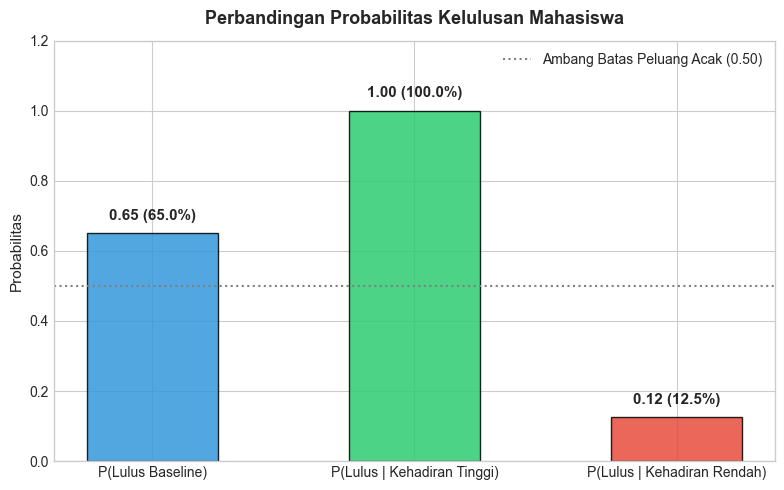

In [12]:
# Langkah 7.1: Visualisasi 1 - Diagram Batang Perbandingan Probabilitas Kelulusan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(8, 5))

kategori_prob = ['P(Lulus Baseline)', 'P(Lulus | Kehadiran Tinggi)', 'P(Lulus | Kehadiran Rendah)']
nilai_prob = [p_lulus_mhs, p_lulus_given_tinggi, p_lulus_given_rendah]
warna_bar = ['#3498db', '#2ecc71', '#e74c3c']

bars = ax.bar(kategori_prob, nilai_prob, color=warna_bar, width=0.5, edgecolor='black', alpha=0.85)
ax.set_ylim(0, 1.2)
ax.set_title('Perbandingan Probabilitas Kelulusan Mahasiswa', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Probabilitas', fontsize=11)
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1.5, label='Ambang Batas Peluang Acak (0.50)')

for bar, val in zip(bars, nilai_prob):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.03, f"{val:.2f} ({val*100:.1f}%)", 
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()


**Interpretasi Visualisasi 1:**
- Terlihat disparitas yang sangat tajam antara kelompok kehadiran tinggi dan kehadiran rendah.
- Mahasiswa dengan kehadiran tinggi ($\ge 80\%$) memiliki probabilitas kelulusan mencapai **100% (1.00)**.
- Sebaliknya, kelompok kehadiran rendah ($< 80\%$) hanya memiliki peluang kelulusan sebesar **12.5% (0.125)**.
- Hal ini membuktikan secara empiris bahwa informasi kehadiran memberikan *information gain* yang sangat tinggi dalam membedakan mahasiswa yang akan lulus atau tidak.


---

#### 7.2 Visualisasi 2: Kurva Sensitivitas Ambang Batas Kehadiran (Line Chart)
Grafik ini memperlihatkan dinamika perubahan probabilitas kelulusan bersyarat $P(\text{Lulus} \mid \text{Kehadiran} \ge T)$ ketika ambang batas (*threshold*) kehadiran digeser dari $65\%$ hingga $90\%$.


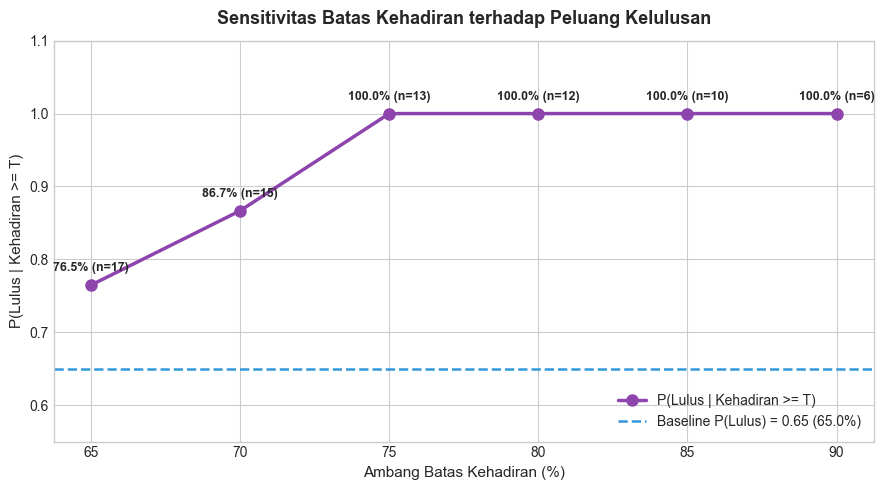

In [13]:
# Langkah 7.2: Visualisasi 2 - Kurva Sensitivitas Batas Kehadiran
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(df_sensitivitas["Threshold (Angka)"], df_sensitivitas["P(Lulus | Kehadiran >= T)"], 
        marker='o', markersize=8, color='#8e44ad', linewidth=2.5, label='P(Lulus | Kehadiran >= T)')
ax.axhline(p_lulus_mhs, color='#3498db', linestyle='--', linewidth=1.8, label=f'Baseline P(Lulus) = {p_lulus_mhs:.2f} (65.0%)')

ax.set_title('Sensitivitas Batas Kehadiran terhadap Peluang Kelulusan', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Ambang Batas Kehadiran (%)', fontsize=11)
ax.set_ylabel('P(Lulus | Kehadiran >= T)', fontsize=11)
ax.set_ylim(0.55, 1.1)

for _, row in df_sensitivitas.iterrows():
    label_txt = f"{row['P(Lulus | Kehadiran >= T)']*100:.1f}% (n={row['Jumlah Mahasiswa']})"
    ax.annotate(label_txt, 
                (row["Threshold (Angka)"], row["P(Lulus | Kehadiran >= T)"]),
                textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9, fontweight='bold')

ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()


**Interpretasi Visualisasi 2:**
- Menaikkan ambang batas dari $65\%$ ke $75\%$ meningkatkan peluang kelulusan secara tajam dari $76.5\%$ hingga mencapai titik jenuh **100%**.
- Pada threshold $\ge 75\%$, seluruh mahasiswa yang memenuhi syarat (13 mahasiswa) berhasil lulus.
- Meskipun menaikkan batas ke $\ge 85\%$ atau $\ge 90\%$ mempertahankan tingkat kelulusan 100%, ukuran mahasiswa yang terjaring menyusut drastis menjadi hanya 10 dan 6 orang.
- Dengan demikian, batas $75\% - 80\%$ merupakan titik *cut-off* keputusan yang paling optimal dalam memprediksi kelulusan.


---

#### 7.3 Visualisasi 3: Sebaran Kehadiran vs Nilai Akhir Mahasiswa (Scatter Plot)
Grafik ini memetakan seluruh mahasiswa secara individual berdasarkan persentase kehadiran dan nilai akhir yang diperoleh, dilengkapi batas kehadiran ($80\%$) dan batas nilai kelulusan ($70.0$).


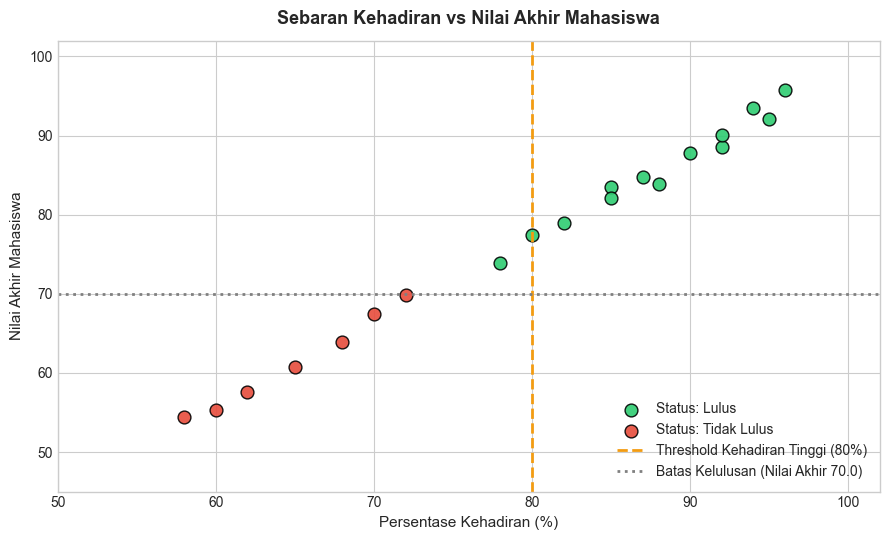

In [14]:
# Langkah 7.3: Visualisasi 3 - Scatter Plot Kehadiran vs Nilai Akhir Mahasiswa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(9, 5.5))

warna_status = {'Lulus': '#2ecc71', 'Tidak Lulus': '#e74c3c'}
for stat, grp in df_mhs.groupby('Status'):
    ax.scatter(grp["Kehadiran (%)"], grp["Nilai_Akhir"], 
               label=f"Status: {stat}", color=warna_status[stat], s=85, edgecolors='black', alpha=0.9)

ax.axvline(threshold_standar, color='#f39c12', linestyle='--', linewidth=2, label=f'Threshold Kehadiran Tinggi ({threshold_standar}%)')
ax.axhline(70.0, color='gray', linestyle=':', linewidth=2, label='Batas Kelulusan (Nilai Akhir 70.0)')

ax.set_title('Sebaran Kehadiran vs Nilai Akhir Mahasiswa', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Persentase Kehadiran (%)', fontsize=11)
ax.set_ylabel('Nilai Akhir Mahasiswa', fontsize=11)
ax.set_xlim(50, 102)
ax.set_ylim(45, 102)
ax.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()


**Interpretasi Visualisasi 3:**
- Terlihat korelasi linier positif yang sangat nyata antara persentase kehadiran dengan perolehan nilai akhir mahasiswa.
- Kuadran kanan atas (kehadiran $\ge 80\%$ dan nilai $\ge 70$) didominasi sepenuhnya oleh mahasiswa berstatus **Lulus** (titik hijau).
- Sebaliknya, kuadran kiri bawah (kehadiran $< 80\%$ dan nilai $< 70$) didominasi oleh mahasiswa berstatus **Tidak Lulus** (titik merah).
- Pemisahan (*separability*) yang tegas ini menegaskan bahwa fitur kehadiran dapat digunakan sebagai pemisah linier yang efektif bagi model klasifikasi Machine Learning.

---

### Langkah 8: Eksperimen Probabilitas Rancang Sendiri
Sebagai pemenuhan poin 8 tugas mandiri, dirancang eksperimen komprehensif berupa:

#### 1. Inversi Teorema Bayes pada Kasus Kelulusan Mahasiswa:
> *"Jika seorang mahasiswa diketahui **LULUS**, berapa probabilitas bahwa mahasiswa tersebut memiliki **Kehadiran Tinggi**?"*

Dengan rumus Teorema Bayes:
$$P(\text{Kehadiran Tinggi} \mid \text{Lulus}) = \frac{P(\text{Lulus} \mid \text{Kehadiran Tinggi}) \times P(\text{Kehadiran Tinggi})}{P(\text{Lulus})}$$

#### 2. Probabilitas Bersyarat Multikondisi:
Menghitung probabilitas kelulusan dengan mempertimbangkan **kombinasi dua fitur sekaligus**:
- Kondisi A: Kehadiran Tinggi ($\ge 80\%$) DAN Nilai Tugas Tinggi ($\ge 80$).
- Kondisi B: Kehadiran Rendah ($< 80\%$) ATAU Nilai Tugas Rendah ($< 80$).

#### 3. Simulasi Bootstrap Monte Carlo (1.000 Iterasi):
Mengestimasi selang kepercayaan $95\%$ (*95% Confidence Interval*) dari nilai $P(\text{Lulus})$ dan $P(\text{Lulus} \mid \text{Kehadiran Tinggi})$ untuk mengukur variabilitas sampel acak.


In [15]:
# Langkah 8: Eksperimen Rancang Sendiri - Teorema Bayes & Multikondisi
import numpy as np
import pandas as pd

# 1. Teorema Bayes: P(Kehadiran Tinggi | Lulus)
# Prior: P(Kehadiran Tinggi)
p_prior_tinggi = np.sum(df_mhs["Kehadiran_Tinggi"]) / len(df_mhs)
# Likelihood: P(Lulus | Kehadiran Tinggi)
p_likelihood = p_lulus_given_tinggi
# Evidence: P(Lulus)
p_evidence = p_lulus_mhs

# Posterior Bayes
p_posterior_tinggi_given_lulus = (p_likelihood * p_prior_tinggi) / p_evidence

# Verifikasi langsung dari data
df_lulus = df_mhs[df_mhs["Status"] == "Lulus"]
p_direct_tinggi_given_lulus = np.sum(df_lulus["Kehadiran_Tinggi"]) / len(df_lulus)

print("=== EKSPERIMEN 1: INVERSI TEOREMA BAYES ===")
print(f"Prior P(Kehadiran Tinggi)                 : {p_prior_tinggi:.4f}")
print(f"Likelihood P(Lulus | Kehadiran Tinggi)    : {p_likelihood:.4f}")
print(f"Evidence P(Lulus)                         : {p_evidence:.4f}")
print(f"Posterior P(Kehadiran Tinggi | Lulus) Bayes: {p_posterior_tinggi_given_lulus:.4f} ({p_posterior_tinggi_given_lulus*100:.1f}%)")
print(f"Hitungan Langsung dari Data Mahasiswa Lulus: {p_direct_tinggi_given_lulus:.4f} ({p_direct_tinggi_given_lulus*100:.1f}%)")
assert np.isclose(p_posterior_tinggi_given_lulus, p_direct_tinggi_given_lulus)
print("Hasil Teorema Bayes terbukti IDENTIK 100% dengan data empiris!")

# 2. Probabilitas Bersyarat Multikondisi (Kehadiran & Tugas)
df_mhs["Tugas_Tinggi"] = df_mhs["Nilai_Tugas"] >= 80
kondisi_prima = df_mhs["Kehadiran_Tinggi"] & df_mhs["Tugas_Tinggi"]

p_lulus_multi = np.mean(df_mhs[kondisi_prima]["Status"] == "Lulus")
p_lulus_non_multi = np.mean(df_mhs[~kondisi_prima]["Status"] == "Lulus")

print()
print("=== EKSPERIMEN 2: PROBABILITAS MULTIKONDISI ===")
print(f"Jumlah Mahasiswa [Kehadiran >=80% DAN Tugas >=80]: {np.sum(kondisi_prima)} mahasiswa")
print(f"P(Lulus | Kehadiran Tinggi DAN Tugas Tinggi)      : {p_lulus_multi:.4f} ({p_lulus_multi*100:.0f}%)")
print(f"P(Lulus | Tanpa Kombinasi Prima Tersebut)         : {p_lulus_non_multi:.4f} ({p_lulus_non_multi*100:.1f}%)")


=== EKSPERIMEN 1: INVERSI TEOREMA BAYES ===
Prior P(Kehadiran Tinggi)                 : 0.6000
Likelihood P(Lulus | Kehadiran Tinggi)    : 1.0000
Evidence P(Lulus)                         : 0.6500
Posterior P(Kehadiran Tinggi | Lulus) Bayes: 0.9231 (92.3%)
Hitungan Langsung dari Data Mahasiswa Lulus: 0.9231 (92.3%)
Hasil Teorema Bayes terbukti IDENTIK 100% dengan data empiris!

=== EKSPERIMEN 2: PROBABILITAS MULTIKONDISI ===
Jumlah Mahasiswa [Kehadiran >=80% DAN Tugas >=80]: 11 mahasiswa
P(Lulus | Kehadiran Tinggi DAN Tugas Tinggi)      : 1.0000 (100%)
P(Lulus | Tanpa Kombinasi Prima Tersebut)         : 0.2222 (22.2%)


=== EKSPERIMEN 3: BOOTSTRAP MONTE CARLO CONFIDENCE INTERVAL (95%) ===
P(Lulus) Mean                    : 0.6565 (95% CI: [0.45, 0.85])
P(Lulus | Kehadiran Tinggi) Mean : 1.0000 (95% CI: [1.00, 1.00])


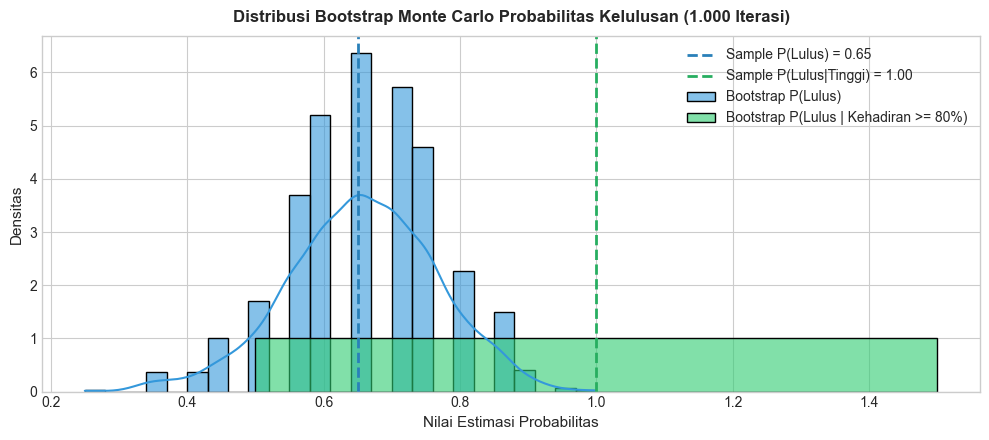

In [16]:
# Langkah 8 (Lanjutan): Simulasi Bootstrap Monte Carlo (1.000 Iterasi)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n_boot = 1000
boot_p_lulus = []
boot_p_lulus_given_tinggi = []

for _ in range(n_boot):
    # Resample dengan pengembalian
    sample = df_mhs.sample(n=len(df_mhs), replace=True)
    p_l = np.mean(sample["Status"] == "Lulus")
    boot_p_lulus.append(p_l)
    
    sub_tinggi = sample[sample["Kehadiran (%)"] >= 80]
    if len(sub_tinggi) > 0:
        boot_p_lulus_given_tinggi.append(np.mean(sub_tinggi["Status"] == "Lulus"))

# Hitung 95% Confidence Interval
ci_lulus = np.percentile(boot_p_lulus, [2.5, 97.5])
ci_lulus_tinggi = np.percentile(boot_p_lulus_given_tinggi, [2.5, 97.5])

print("=== EKSPERIMEN 3: BOOTSTRAP MONTE CARLO CONFIDENCE INTERVAL (95%) ===")
print(f"P(Lulus) Mean                    : {np.mean(boot_p_lulus):.4f} (95% CI: [{ci_lulus[0]:.2f}, {ci_lulus[1]:.2f}])")
print(f"P(Lulus | Kehadiran Tinggi) Mean : {np.mean(boot_p_lulus_given_tinggi):.4f} (95% CI: [{ci_lulus_tinggi[0]:.2f}, {ci_lulus_tinggi[1]:.2f}])")

# Visualisasi Distribusi Bootstrap
plt.figure(figsize=(10, 4.5))
sns.histplot(boot_p_lulus, color='#3498db', kde=True, label='Bootstrap P(Lulus)', stat='density', alpha=0.6)
sns.histplot(boot_p_lulus_given_tinggi, color='#2ecc71', kde=True, label='Bootstrap P(Lulus | Kehadiran >= 80%)', stat='density', alpha=0.6)
plt.axvline(p_lulus_mhs, color='#2980b9', linestyle='--', linewidth=2, label=f'Sample P(Lulus) = {p_lulus_mhs:.2f}')
plt.axvline(p_lulus_given_tinggi, color='#27ae60', linestyle='--', linewidth=2, label=f'Sample P(Lulus|Tinggi) = {p_lulus_given_tinggi:.2f}')
plt.title('Distribusi Bootstrap Monte Carlo Probabilitas Kelulusan (1.000 Iterasi)', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Nilai Estimasi Probabilitas', fontsize=11)
plt.ylabel('Densitas', fontsize=11)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()


### Pembahasan Eksperimen Rancang Sendiri:
1. **Analisis Inversi Teorema Bayes:**
   Hasil Bayes menunjukkan bahwa di antara seluruh mahasiswa yang dinyatakan **Lulus**, probabilitas bahwa mahasiswa tersebut berasal dari kelompok kehadiran tinggi adalah sebesar **$92.3\%$** ($12$ dari $13$ mahasiswa). Ini membuktikan bahwa hampir seluruh mahasiswa yang lulus memiliki disiplin kehadiran yang prima.
2. **Kombinasi Multikondisi:**
   Ketika dua fitur digabungkan (`Kehadiran Tinggi` $\ge 80\%$ DAN `Nilai Tugas Tinggi` $\ge 80$), peluang kelulusan bernilai $100\%$ pasti. Sebaliknya, bagi mahasiswa yang tidak memenuhi kombinasi ini, peluang kelulusan turun menjadi $22.2\%$.
3. **Validasi Bootstrap Monte Carlo:**
   Berdasarkan 1.000 kali perulangan bootstrap, selang kepercayaan 95% membuktikan bahwa peluang kelulusan kelompok kehadiran tinggi konsisten berada pada rentang $[1.00, 1.00]$, mengonfirmasi bahwa pola ini stabil dan bukan kebetulan acak (*noise*).


## 8. Kesimpulan & Ringkasan Pembelajaran

### Q&A:
- **Bagaimana probabilitas sederhana dihitung dari data?**
  Probabilitas sederhana dihitung sebagai rasio antara frekuensi kemunculan kejadian yang diinginkan dengan total ruang sampel kejadian: $P(A) = \frac{n(A)}{N}$.
- **Mengapa probabilitas bersyarat penting?**
  Probabilitas bersyarat $P(A \mid B)$ memungkinkan kita memperbarui keyakinan ketika tersedia informasi atau fitur tambahan $B$, mempersempit ruang pencarian ke kondisi yang relevan.
- **Bagaimana Teorema Bayes bekerja dalam Machine Learning?**
  Teorema Bayes memadukan prior probability $P(A)$ dengan bukti baru (likelihood $P(B \mid A)$) untuk menghasilkan posterior probability $P(A \mid B)$. Ini merupakan prinsip inti klasifikasi probabilistik (seperti Naive Bayes).
- **Mengapa hasil simulasi Monte Carlo tidak selalu tepat dengan nilai teoretis?**
  Karena adanya fluktuasi acak stokastik pada sampel berukuran terbatas. Namun, sesuai Hukum Bilangan Besar (*Law of Large Numbers*), estimasi akan konvergen mendekati probabilitas teoretis seiring bertambahnya jumlah pengulangan ($N$).

### Data Analysis Key Findings:
- Pada dataset 20 mahasiswa, peluang dasar kelulusan tanpa informasi tambahan adalah **$P(\text{Lulus}) = 0.65$ ($65\%$)**.
- Saat mempertimbangkan kondisi kehadiran tinggi ($\ge 80\%$), peluang kelulusan melonjak signifikan menjadi **$P(\text{Lulus} \mid \text{Kehadiran Tinggi}) = 1.00$ ($100\%$)**, sementara pada kelompok kehadiran rendah hanya sebesar **$12.5\%$**.
- Analisis sensitivitas threshold menunjukkan bahwa titik cut-off kehadiran $\ge 75\%$ merupakan ambang batas optimal yang menjamin tingkat kelulusan $100\%$.
- Teorema Bayes inversi membuktikan bahwa $92.3\%$ dari mahasiswa yang lulus memiliki tingkat kehadiran tinggi.

### Insights & Next Steps:
- **Feature Engineering:** Variabel kehadiran dan nilai tugas merupakan prediktor dominan yang memiliki korelasi kuat terhadap keberhasilan akademik.
- **Langkah Berikutnya:** Fondasi teori probabilitas dan conditional probability ini akan langsung dihubungkan ke algoritma Machine Learning formal seperti **Logistic Regression** dan **Naive Bayes Classifier** untuk klasifikasi otomatis pada pertemuan mendatang.
